# Lab 03: Is There a Planet in Your Light Curve?

**ASTR 457, Fall 2026, posted Thu Sep 17, due Wed Sep 23 by Noon (fork → PR, as always)**

*Why this lab: transit fitting by maximum likelihood is how thousands of planets, including every temperate world around an M dwarf that David Charbonneau will talk about at the Sep 29 colloquium, were actually measured, and the gap between an error bar computed the lazy way and one computed honestly is exactly the gap between a claim that survives referees and one that doesn't.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `t_days`
(time from the start of a ~27-day TESS-style observing sector, 30-minute cadence, with a
~1-day data gap in the middle), `flux_rel` (relative flux, normalized near 1), and
`sigma_flux` (the per-point **white-noise** uncertainty). Your star is a nearby M dwarf
with a candidate transiting super-Earth. The light curve contains: the transit train,
slow instrumental systematics (drifts over days), and, as you will discover, noise
that is not entirely captured by `sigma_flux`. I know the true mid-transit time $t_0$,
period $P$, depth $\delta$, and duration $T$ for your dataset. You don't, you can't look
them up, and your classmates' planets are different from yours.

**How this is graded.** As always: on whether your answers are *right* and your
uncertainties are *honest*. Your reported depth and period are compared to your truth in
units of your own reported uncertainty. Anti-sandbagging cap: your $\sigma_\delta$ may
not exceed 3× a reference uncertainty I compute for your dataset; defensive error bars
lose points just like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and
document it in Part 4. You may be selected to defend this lab in person (the practice
round was Sep 15; the real ones use the same format).

## The transit model (given)

Use this five-parameter periodic trapezoid, the small-planet limit of Mandel & Agol
(2002), the same model from Tuesday's lecture. The parameters are
$\theta = (t_0, P, \delta, T, F_0)$: mid-transit time of the first transit, period,
depth, total duration, and out-of-transit baseline flux. Ingress and egress each span
20% of the duration.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def transit_model(t, t0, period, depth, duration, baseline, ingress_frac=0.2):
    """Periodic trapezoidal transit train."""
    ph = ((t - t0 + 0.5 * period) % period) - 0.5 * period
    half = duration / 2.
    ing = ingress_frac * duration
    f = np.ones_like(t)
    inside = np.abs(ph) < half
    full = np.abs(ph) < (half - ing)
    f[inside] = 1. - depth * np.clip((half - np.abs(ph[inside])) / ing, 0., 1.)
    f[full] = 1. - depth
    return baseline * f

NETID = 'ms155'  # <-- set this
d = np.genfromtxt(f'/Users/mtscl/ast457_2026_Fall/labs/03/data/{NETID}.csv', delimiter=',', names=True, skip_header=1)
t, flux, sigma = d['t_days'], d['flux_rel'], d['sigma_flux']
print(f'{len(t)} points spanning {t[-1]:.1f} days; stated sigma = {sigma[0]*1e3:.2f} ppt')

1263 points spanning 27.4 days; stated sigma = 0.96 ppt


## Part 1: Find the planet (20%)

1. Plot the raw light curve. Identify the slow systematic trend and the transits.
2. **Detrend** the light curve. Be deliberate: state your method (median filter, spline,
   polynomial per segment, your choice), your smoothing scale, and *why that scale
   can't eat your transits*. Plot raw, trend, and detrended flux.
3. From the detrended curve, read off by eye: approximate $t_0$, $P$, depth, duration:
   your initial guesses for Part 2.
4. Compare the out-of-transit scatter of your detrended flux to the stated `sigma_flux`.
   Are they consistent? Say what you conclude (a sentence is fine, and you'll need this
   observation in Parts 2 and 3).

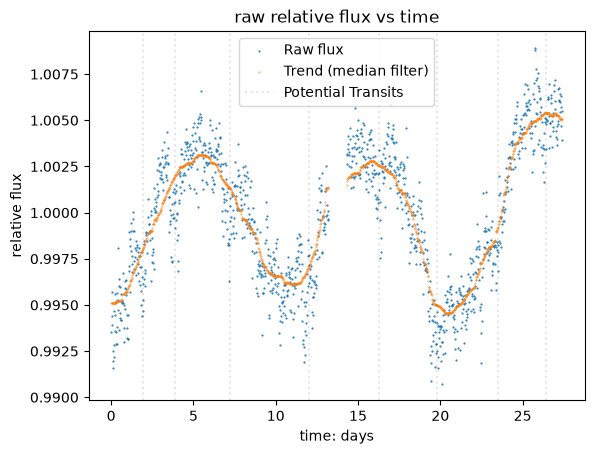

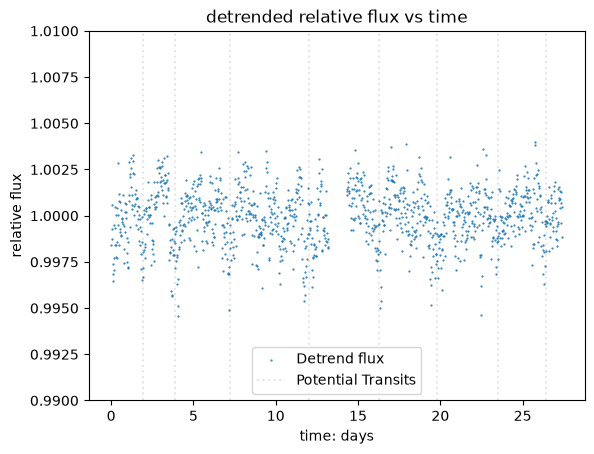

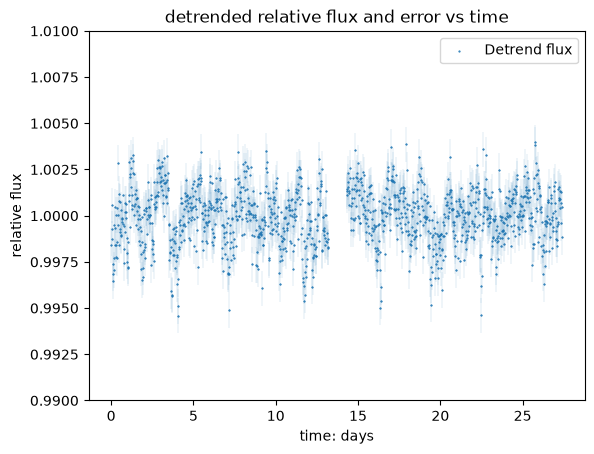

In [2]:
# Part 1: your work here
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
from scipy.ndimage import median_filter
from scipy.interpolate import UnivariateSpline
tabledat = ascii.read('/Users/mtscl/ast457_2026_Fall/labs/03/data/ms155.csv', header_start=0, data_start=1, delimiter=',')
t = tabledat["t_days"]
flux = tabledat["flux_rel"]
err = tabledat["sigma_flux"]
fig1 = plt.figure()
plt.scatter(t,flux,s=.3,label="Raw flux")
medft = median_filter(flux,size =131)
fluxdtrnd = flux - medft+1
plt.scatter(t,medft,s=.1,label="Trend (median filter)")
plt.axvline(1.95, c="k", label="Potential Transits", linestyle=":",alpha=.1)
plt.axvline(3.9, c="k", linestyle=":",alpha=.1)
plt.axvline(7.2, c="k", linestyle=":",alpha=.1)
plt.axvline(12, c="k", linestyle=":",alpha=.1)
plt.axvline(16.3, c="k", linestyle=":",alpha=.1)
plt.axvline(19.8, c="k", linestyle=":",alpha=.1)
plt.axvline(23.5, c="k", linestyle=":",alpha=.1)
plt.axvline(26.4, c="k", linestyle=":",alpha=.1)
plt.xlabel("time: days")
plt.ylabel("relative flux")
plt.title("raw relative flux vs time")
plt.legend()
fig2 = plt.figure()
plt.scatter(t,fluxdtrnd,s=.3,label="Detrend flux")
plt.axvline(1.95, c="k", label="Potential Transits", linestyle=":",alpha=.1)
plt.axvline(3.9, c="k", linestyle=":",alpha=.1)
plt.axvline(7.2, c="k", linestyle=":",alpha=.1)
plt.axvline(12, c="k", linestyle=":",alpha=.1)
plt.axvline(16.3, c="k", linestyle=":",alpha=.1)
plt.axvline(19.8, c="k", linestyle=":",alpha=.1)
plt.axvline(23.5, c="k", linestyle=":",alpha=.1)
plt.axvline(26.4, c="k", linestyle=":",alpha=.1)
plt.ylim(.99,1.01)
plt.xlabel("time: days")
plt.ylabel("relative flux")
plt.title("detrended relative flux vs time")
plt.legend()
fig3 = plt.figure()
plt.scatter(t,fluxdtrnd,s=.3,label="Detrend flux")
plt.errorbar(t,fluxdtrnd,err,fmt="o",linewidth=.1,markersize=.1)
plt.ylim(.99,1.01)
plt.xlabel("time: days")
plt.ylabel("relative flux")
plt.title("detrended relative flux and error vs time")
plt.legend()

**ANSWERS (initial guesses + scatter check):**

*The scale ive chosen for the median fit was 131 which is significantly bigger than all the transits as to not dip with them and By eye, it seems the first transit has t_0 = 1.95, P = 2, D = .0025,duration = .5, baseline = 1.
As for scatter detrended is slightly larger for a few points than the listed error but still well within 3 times the error and a majority of points are within 1 error bar, so it seems reasonable.*

## Part 2: The measurement you'd publish (40%)

1. Write the Gaussian log-likelihood for the transit model and maximize it
   (`scipy.optimize.minimize`; Nelder-Mead first, as in lecture). Fit all five
   parameters. Plot the phase-folded data with your best-fit model, and the residuals.
2. Estimate uncertainties **two ways**:
   - from the curvature of the log-likelihood at the maximum (the inverse Hessian,
     lecture method), and
   - by **bootstrap**, and think about *what* you resample: if you resample individual
     points, what are you assuming about the noise? A block bootstrap (resample
     contiguous chunks of residuals, e.g. 1-day blocks) makes a different assumption.
     Do both point-wise and block versions and compare.
3. The three uncertainty estimates for the depth will not all agree. Explain the pattern
   using your Part 1 scatter observation. Which noise property do the Hessian and the
   point-wise bootstrap both assume that your residuals violate? Demonstrate that
   violation with a plot or a number (hint: bin your residuals in ~5-hour bins and
   compare the binned scatter to what independent noise predicts).
4. **Commit to final answers**: $\delta \pm \sigma_\delta$, $P \pm \sigma_P$,
   $t_0 \pm \sigma_{t_0}$, and justify which uncertainty estimate you adopted.

C:\Users\mtscl\AppData\Local\Temp\ipykernel_23636\4064055981.py:9: RuntimeWarning: divide by zero encountered in log
  return -np.sum(np.log(p))
C:\Users\mtscl\anaconda3\envs\astr457\Lib\site-packages\scipy\optimize\_numdiff.py:710: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
C:\Users\mtscl\AppData\Local\Temp\ipykernel_23636\4064055981.py:9: RuntimeWarning: divide by zero encountered in log
  return -np.sum(np.log(p))
C:\Users\mtscl\AppData\Local\Temp\ipykernel_23636\4064055981.py:9: RuntimeWarning: divide by zero encountered in log
  return -np.sum(np.log(p))
C:\Users\mtscl\anaconda3\envs\astr457\Lib\site-packages\scipy\optimize\_numdiff.py:710: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
C:\Users\mtscl\AppData\Local\Temp\ipykernel_23636\4064055981.py:9: RuntimeWarning: divide by zero encountered in log
  return -np.sum(np.log(p))
C:\Users\mtscl\AppData\Local\Temp\ipykernel_23636\

depth is 0.00076773, period is 2.0284, and t_0 is 1.8911               duration is 0.9221
errdepth is 0.000047732, errperiod is 0.00022015, and errt_0 is 0.00076592 for curviture of the log likelihood
errdepth is 0.000015177, errperiod is 0.00150903, and errt_0 is 0.01048541 for bootstrap point
errdepth is 0.000027136, errperiod is 0.00305757, and errt_0 is 0.01754181 for bootstrap block


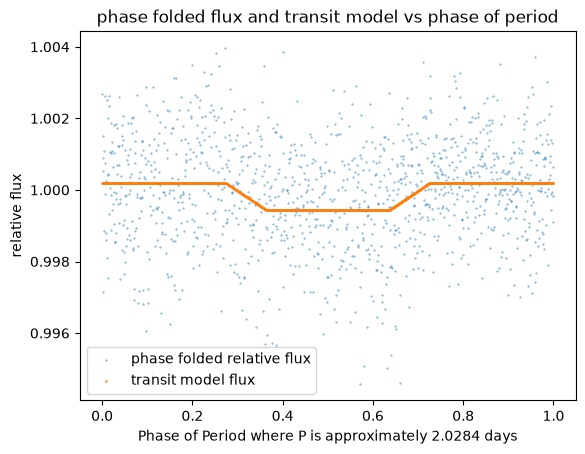

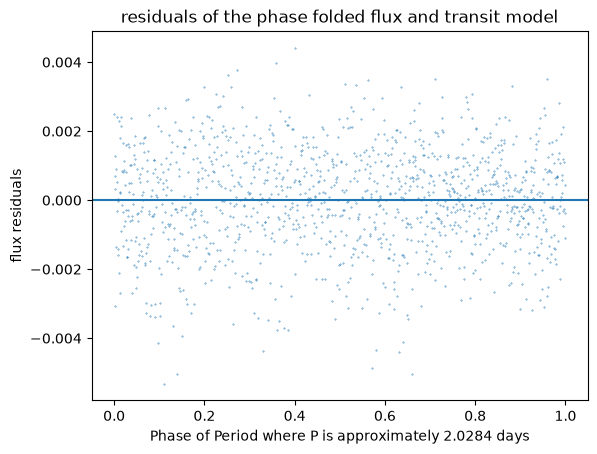

<Figure size 640x480 with 0 Axes>

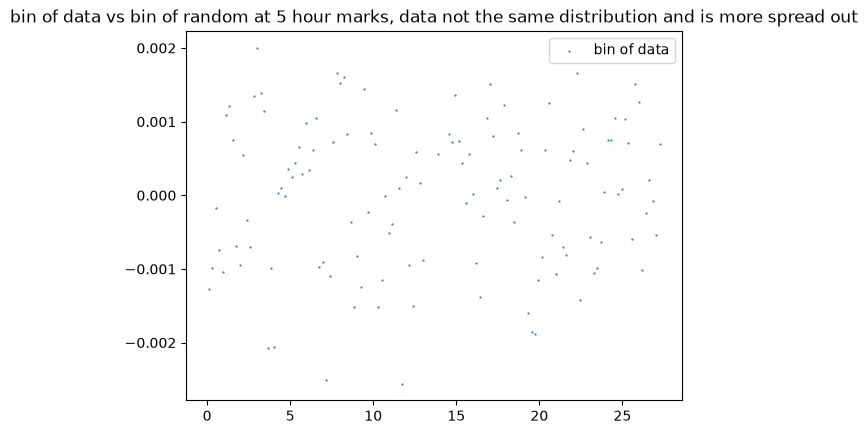

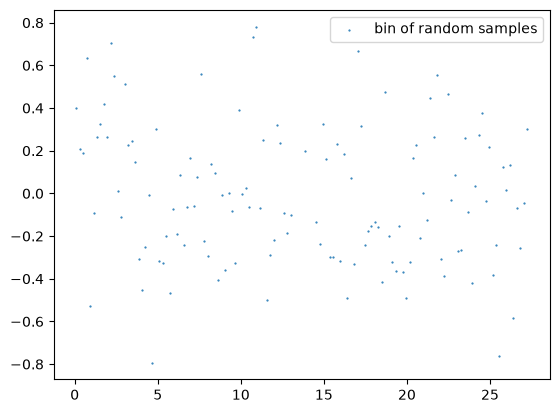

In [3]:
# Part 2: your work here
from numpy.random import normal
def loglike(params, t,y,err):
    t0, P, depth,duration,baseline = params
    ymodel = transit_model(t, t0, P, depth, duration, baseline)
    p = (1/(err*np.sqrt(2*np.pi))) * np.exp(-(y-ymodel)**2/(2*err**2))
    #likeli = np.prod(p)
    #loglikeli = np.log(likeli)
    return -np.sum(np.log(p))
loglike([1.9,2, .0025, .5, 1],t,fluxdtrnd,err)
#cuttran = t > 2.7
minimlike = minimize(loglike,[1.9, 2, .0025, .5, 1],args=(t,fluxdtrnd,err))
t_0, P, delta, duration, baseline = minimlike.x
phase = ((t - t_0)/P+.5)%1 
modeltran = transit_model(t, t_0, P, delta, duration, baseline)
fig4 = plt.figure()
plt.scatter(phase,fluxdtrnd,s=.1,label="phase folded relative flux")
plt.scatter(phase,modeltran,s=.5,label="transit model flux")
plt.xlabel(f"Phase of Period where P is approximately {P:.4f} days")
plt.ylabel("relative flux")
plt.title("phase folded flux and transit model vs phase of period")
plt.legend()
fig5 = plt.figure()
plt.scatter(phase,fluxdtrnd-modeltran,s=.1)
plt.axhline(0,0)
plt.xlabel(f"Phase of Period where P is approximately {P:.4f} days")
plt.ylabel("flux residuals")
plt.title("residuals of the phase folded flux and transit model")




fig6 = plt.figure()
h = 10**(-5)
curvdelta = (loglike([t_0, P, delta+h, duration, baseline],t,fluxdtrnd,err) - 2 * loglike([t_0, P, delta, duration, baseline],t,fluxdtrnd,err) + loglike([t_0, P, delta-h, duration, baseline],t,fluxdtrnd,err))/h**2
errcurvdelta = 1/np.sqrt(curvdelta)
curvP = (loglike([t_0, P+h, delta, duration, baseline],t,fluxdtrnd,err) - 2 * loglike([t_0, P, delta, duration, baseline],t,fluxdtrnd,err) + loglike([t_0, P-h, delta, duration, baseline],t,fluxdtrnd,err))/h**2
errcurvP = 1/np.sqrt(curvP)
curvt0 = (loglike([t_0+h, P, delta, duration, baseline],t,fluxdtrnd,err) - 2 * loglike([t_0, P, delta, duration, baseline],t,fluxdtrnd,err) + loglike([t_0-h, P, delta, duration, baseline],t,fluxdtrnd,err))/h**2
errcurvt0 = 1/np.sqrt(curvt0)
def bootstrp(t,flux,err,iterations = 100,seed=7869031):
    rng = np.random.default_rng(seed)
    minimlike = minimize(loglike,[1.9, 2, .001, .5, 1],args=(t,flux,err))
    t_0, P, delta, duration, baseline = minimlike.x
    modeltran = transit_model(t, t_0, P, delta, duration, baseline)
    residuals = flux-modeltran
    t_0, P, delta, duration, baseline = [],[],[],[],[]
    for i in range(iterations):
        resrand = rng.choice(residuals,len(residuals))
        reflux = modeltran + resrand
        minimrand = minimize(loglike,[1.9, 2, .001, .5, 1],args=(t,reflux,err))
        t_0n, Pn, deltan, durationn, baselinen =+ minimrand.x
        t_0.append(t_0n)
        P.append(Pn)
        delta.append(deltan)
        duration.append(durationn)
        baseline.append(baselinen)
    return t_0, P, delta, duration, baseline
t_0boot, Pboot, deltaboot, durationboot, baselineboot = bootstrp(t,fluxdtrnd,err,50)
booterrt0 , booterrP, booterrdelta = (np.array(t_0boot)).std()/np.sqrt(50), (np.array(Pboot)).std()/np.sqrt(50), (np.array(deltaboot)).std()/np.sqrt(50)
def bootstrpblock(t,flux,err,iterations = 100,seed=7869031):
    rng = np.random.default_rng(seed)
    t = t[0:1260]
    flux = flux[0:1260]
    err = err[0:1260]
    minimlike = minimize(loglike,[1.9, 2, .001, .5, 1],args=(t,flux,err))
    t_0, P, delta, duration, baseline = minimlike.x
    modeltran = transit_model(t, t_0, P, delta, duration, baseline)
    residuals = np.split(flux-modeltran,126)
    t_0, P, delta, duration, baseline = [],[],[],[],[]
    for i in range(iterations):
        resrand = rng.choice(residuals,len(residuals))
        reflux = modeltran + np.concatenate(resrand)
        minimrand = minimize(loglike,[1.9, 2, .001, .5, 1],args=(t,reflux,err))
        t_0n, Pn, deltan, durationn, baselinen =+ minimrand.x
        t_0.append(t_0n)
        P.append(Pn)
        delta.append(deltan)
        duration.append(durationn)
        baseline.append(baselinen)
    return t_0, P, delta, duration, baseline
t_0block, Pblock, deltablock, durationblock, baselineblock = bootstrpblock(t,fluxdtrnd,err,50)
blockerrt0 , blockerrP, blockerrdelta = (np.array(t_0block)).std()/np.sqrt(50), (np.array(Pblock)).std()/np.sqrt(50), (np.array(deltablock)).std()/np.sqrt(50)


fig7 = plt.figure()
tbins = np.split(t[0:1260],126)
fluxbins = np.split((fluxdtrnd-modeltran)[0:1260],126)
tbin, fluxbin = [],[]
for i in range(126):
    tbin.append(np.mean(tbins[i]))
    fluxbin.append(np.mean(fluxbins[i]))
tbin = np.array(tbin)
fluxbin = np.array(fluxbin)
plt.scatter(tbin,fluxbin,label="bin of data",s=.3)
plt.title("bin of data vs bin of random at 5 hour marks, data not the same distribution and is more spread out")
plt.legend()
fig8 = plt.figure()
fluxbins =np.split(normal(size=1260) ,126)
tbin, fluxbin = [],[]
for i in range(126):
    tbin.append(np.mean(tbins[i]))
    fluxbin.append(np.mean(fluxbins[i]))
tbin = np.array(tbin)
fluxbin = np.array(fluxbin)
plt.scatter(tbin,fluxbin,label="bin of random samples",s=.3)
plt.legend()

print(f"depth is {delta:.8f}, period is {P:.4f}, and t_0 is {t_0:.4f}               duration is {duration:.4f}")
print(f"errdepth is {errcurvdelta:.9f}, errperiod is {errcurvP:.8f}, and errt_0 is {errcurvt0:.8f} for curviture of the log likelihood")
print(f"errdepth is {booterrdelta:.9f}, errperiod is {booterrP:.8f}, and errt_0 is {booterrt0:.8f} for bootstrap point")
print(f"errdepth is {blockerrdelta:.9f}, errperiod is {blockerrP:.8f}, and errt_0 is {blockerrt0:.8f} for bootstrap block")

**FINAL ANSWER:** $\delta = $ .00076773 $\pm$ .000027136 ppt, $P = $ 2.0284 $\pm$ .00305757 d, $t_0 = $ 1.8911 $\pm$ .01754181 d

**Which uncertainty and why (a short paragraph):**

*I ended up using the bootstrap block estimate as it was signficantly more robust than the likelihood estimate where the second derivative never seemed to settle. The block has larger error bars than the bootstrap point which isn't a bad thing considering the estimates are multiple orders of magnitude smaller than the value. On top of this, the values are not completely independent of each other so blocking them in groups of about 5 hours can help as well.*

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis
of this exact problem, produced by an AI assistant. It runs top to bottom without
errors, the phase-folded plot looks professional, and the prose is fluent. It is also
wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks don't
count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset. Show, with a number or a
   plot, what the error does to the inference. "This is bad practice" is not a
   demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

You've done this once before, on Lab 01. Notice how much faster you are at it now.
That speed is the skill this course is building.

**REFEREE REPORT:**

*Flaw 1: The window at which the raw data was put into trend with median filter was too small and "ate" the transits*

*Flaw 2: It used the same error/sigma for the whole fit*

*Flaw 3: It used completely off guesses for its fit*

window is only = 12, which is not only much smaller than the transits, so it 'eats' them, but also does not form a coherent trend
The error used for the entire fit 0.0010734349281169787


C:\Users\mtscl\AppData\Local\Temp\ipykernel_23636\4064055981.py:9: RuntimeWarning: divide by zero encountered in log
  return -np.sum(np.log(p))
C:\Users\mtscl\anaconda3\envs\astr457\Lib\site-packages\scipy\optimize\_numdiff.py:710: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
C:\Users\mtscl\AppData\Local\Temp\ipykernel_23636\4064055981.py:9: RuntimeWarning: divide by zero encountered in log
  return -np.sum(np.log(p))


depth is 0.00076816, period is 2.0293, and t_0 is 1.8799 when using only the one sigma the ai used on my own code to fit the data. The results here are different to mine because of the singular general sigma.
its guesses for its fit were completely off, the guess for period were = 3.07 and depth = 0.0027610000000000134 which are far from the actual answer


C:\Users\mtscl\AppData\Local\Temp\ipykernel_23636\4064055981.py:9: RuntimeWarning: divide by zero encountered in log
  return -np.sum(np.log(p))
C:\Users\mtscl\anaconda3\envs\astr457\Lib\site-packages\scipy\optimize\_numdiff.py:710: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
C:\Users\mtscl\AppData\Local\Temp\ipykernel_23636\4064055981.py:9: RuntimeWarning: divide by zero encountered in log
  return -np.sum(np.log(p))


depth is -0.00069910, period is 3.0713, and t_0 is 2.1896 which are all off as a result of a poor guess


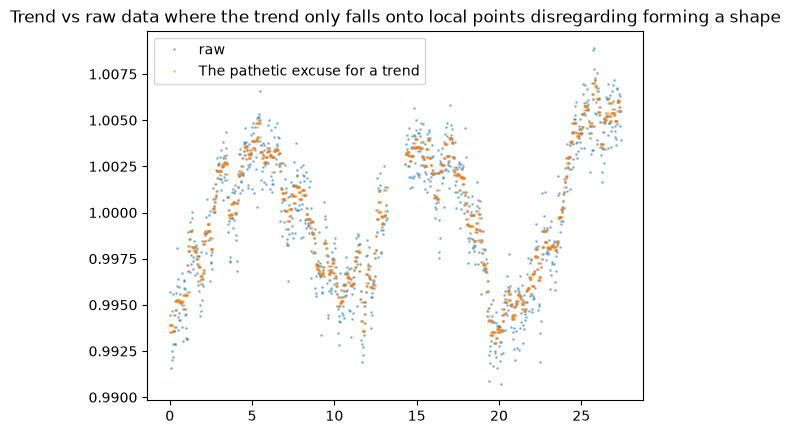

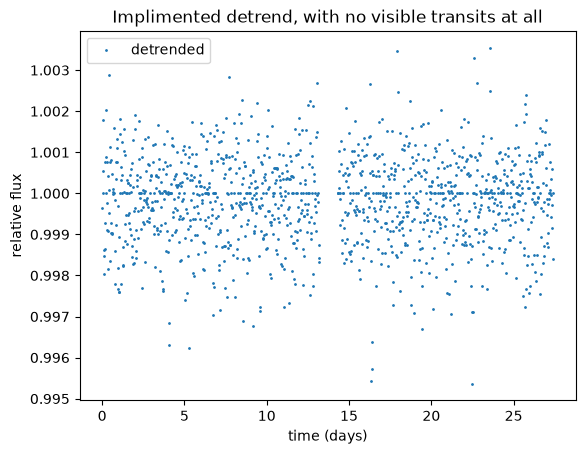

In [4]:
# Part 3: demonstrations here
# this is the code it used to decide the window
cadence = np.median(np.diff(t))
window = max(3, int(round((6.0 / 24.) / cadence)))
trend = median_filter(flux, size=window)
flux_detrended = flux - trend + 1.0
print(f"window is only = {window}, which is not only much smaller than the transits, so it 'eats' them, but also does not form a coherent trend")
fig9 = plt.figure()
plt.plot(t, flux, '.', ms=2, alpha=0.4, label='raw')
plt.plot(t, trend, '.', ms=2, alpha=0.4, label='The pathetic excuse for a trend')
plt.legend()
plt.title("Trend vs raw data where the trend only falls onto local points disregarding forming a shape")
fig10 = plt.figure()
plt.plot(t, flux_detrended, '.', ms=2, label='detrended')
plt.xlabel('time (days)'); plt.ylabel('relative flux'); plt.legend()
plt.title("Implimented detrend, with no visible transits at all")



sigma_emp = np.std(flux_detrended)
print(f"The error used for the entire fit {sigma_emp}")
minimlike = minimize(loglike,[1.9, 2, .0025, .5, 1],args=(t,fluxdtrnd,sigma_emp))
t_0, P, delta, duration, baseline = minimlike.x
print(f"depth is {delta:.8f}, period is {P:.4f}, and t_0 is {t_0:.4f} when using only the one sigma the ai used on my own code to fit the data. The results here are different to mine because of the singular general sigma.")


depth_guess = 1.0 - np.sort(flux_detrended)[20]
print(f"its guesses for its fit were completely off, the guess for period were = 3.07 and depth = {depth_guess} which are far from the actual answer")
minimlike = minimize(loglike,[1.9, 3.07, depth_guess, .5, 1],args=(t,fluxdtrnd,err))
t_0, P, delta, duration, baseline = minimlike.x
print(f"depth is {delta:.8f}, period is {P:.4f}, and t_0 is {t_0:.4f} which are all off as a result of a poor guess")

## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did
   you catch it? Honesty is graded; "I didn't use any" is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers. For each check: what would failure have looked like? (One check you should
   seriously consider: simulate a light curve with parameters you chose, run your whole
   pipeline on it, and see whether you recover what you put in.)

**AI-USE APPENDIX:**

*I asked claude for part 1, "what does it mean to detrend a light curve, how do you do a detrend" and "can you show me an example of detrend with polynomial, spline, and median filtering and give it in python with code". I used the response as a guide to complete part 1. It didn't really get anything wrong as I only asked for specific example code that was meant for me to understand, not copy. The way i worked around wrong ai was by having an example of how to do a specific thing, never soomething I implimented directly. I also asked it for part 2 "how would I apply the gaussian log likelihood to a model that only contains my independent variable and parameters" which just confirmed the likelihood from lecture and was not in code, requiring little of me to change. I also asked "how do you phase fold transit data" to clarify on what that means and requires me to do, again with no code. I also asked it "how do you find the uncertainty using bootstrap" which I used a a guide on what bootstrapping means and entails. I also asked it smaller clarifying questions at which it worked like an advanced google search, I always made sure to confirm information elsewhere though.

*

**VERIFICATION PLAN:**

*For checks, I checked that the residuals matched up with the both the detrend and the phase fold plot with the model. Failure here would have required the model to not match up with the residuals, the model baseline as either to low or high or the data in transit to still be visible and not have cancelled in residuals. I also ran a simulated dataset to test my code and it pulled the expected results (see below)*

C:\Users\mtscl\AppData\Local\Temp\ipykernel_23636\369307057.py:49: RuntimeWarning: divide by zero encountered in log
  return -np.sum(np.log(p))
C:\Users\mtscl\anaconda3\envs\astr457\Lib\site-packages\scipy\optimize\_numdiff.py:710: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
C:\Users\mtscl\AppData\Local\Temp\ipykernel_23636\369307057.py:49: RuntimeWarning: divide by zero encountered in log
  return -np.sum(np.log(p))
C:\Users\mtscl\AppData\Local\Temp\ipykernel_23636\369307057.py:49: RuntimeWarning: divide by zero encountered in log
  return -np.sum(np.log(p))
C:\Users\mtscl\anaconda3\envs\astr457\Lib\site-packages\scipy\optimize\_numdiff.py:710: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
C:\Users\mtscl\AppData\Local\Temp\ipykernel_23636\369307057.py:49: RuntimeWarning: divide by zero encountered in log
  return -np.sum(np.log(p))
C:\Users\mtscl\AppData\Local\Temp\ipykernel_23636\

depth is 0.00048660, period is 2.6378, and t_0 is 1.4334 which is close to the actual value
errdepth is 0.000102436, errperiod is 0.00052837, and errt_0 is 0.00126164 for curviture of the log likelihood
errdepth is 0.000037424, errperiod is 0.01267928, and errt_0 is 0.08733598 for bootstrap point
errdepth is 0.000057807, errperiod is 0.00461382, and errt_0 is 0.03103700 for bootstrap block


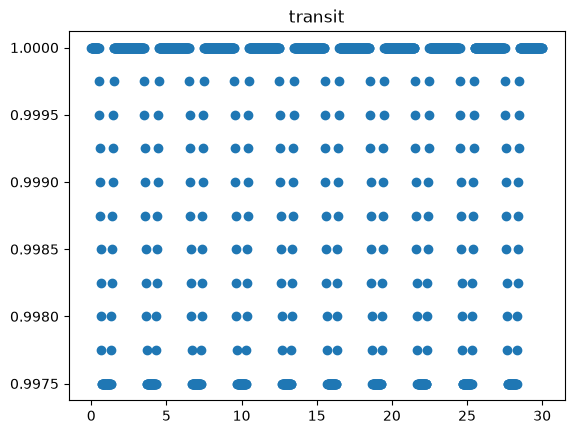

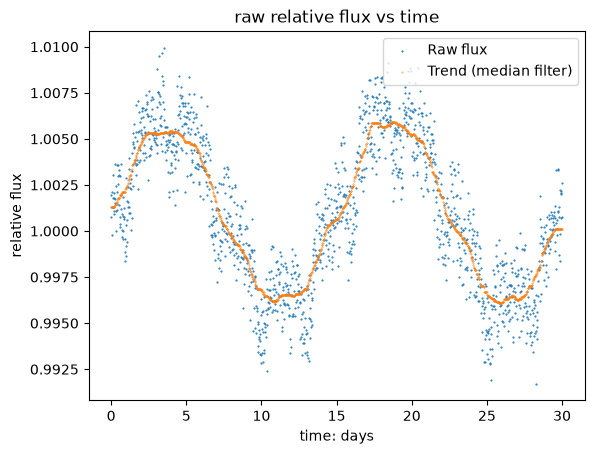

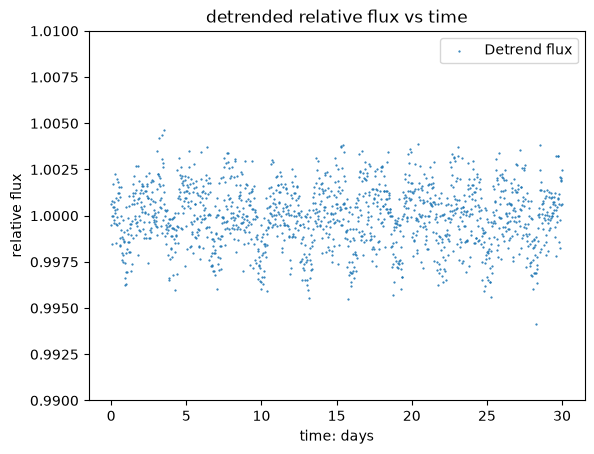

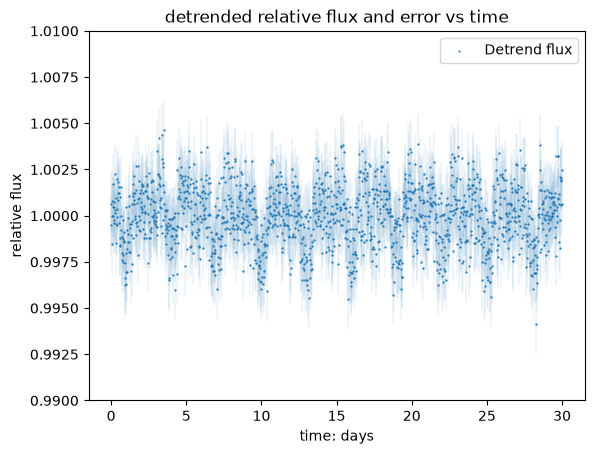

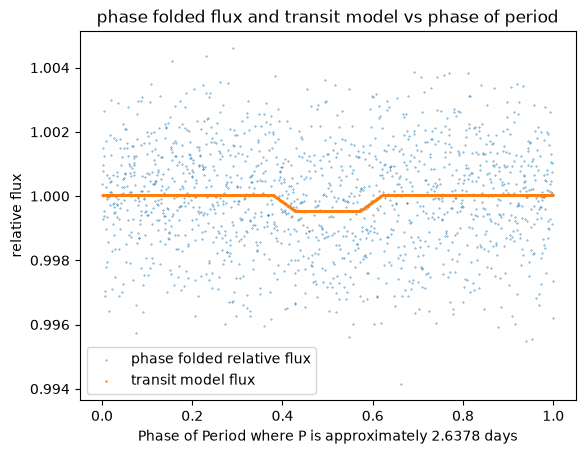

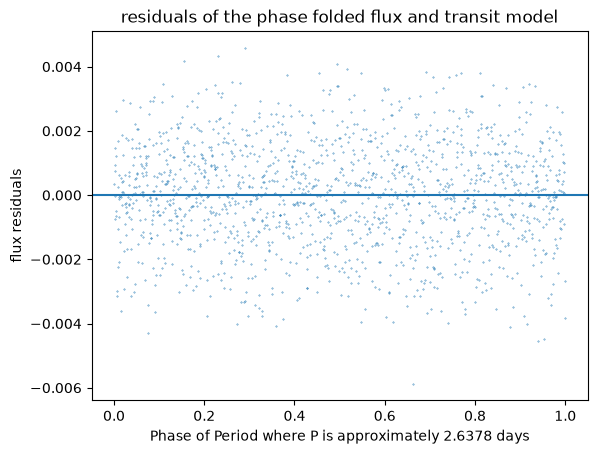

<Figure size 640x480 with 0 Axes>

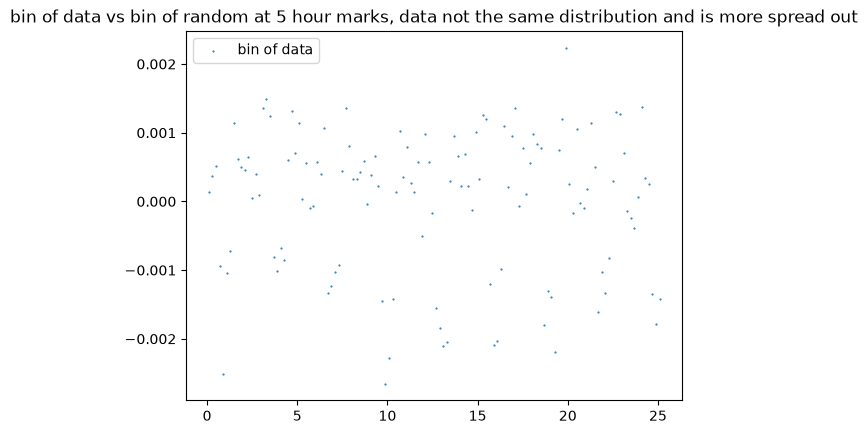

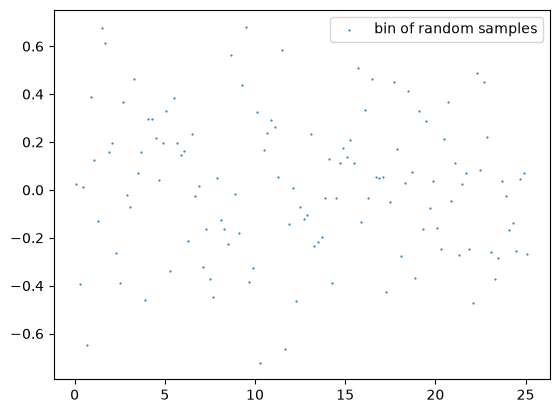

In [5]:
# verification
from numpy.random import uniform
from numpy.random import normal

t = np.linspace(0,30,1501)
ysim = transit_model(t,1,3,.0025, 1, 1)
flux = .005*np.sin(t*2*np.pi/15)+ysim+ .003*uniform(size=1501)+.001*normal(size=1501)
fig20 = plt.figure()
plt.scatter(t,ysim)
plt.title("transit")




fig1 = plt.figure()
plt.scatter(t,flux,s=.3,label="Raw flux")
medft = median_filter(flux,size =131)
fluxdtrnd = flux - medft+1
err = np.std(fluxdtrnd)
plt.scatter(t,medft,s=.1,label="Trend (median filter)")
plt.xlabel("time: days")
plt.ylabel("relative flux")
plt.title("raw relative flux vs time")
plt.legend()
fig2 = plt.figure()
plt.scatter(t,fluxdtrnd,s=.3,label="Detrend flux")
plt.ylim(.99,1.01)
plt.xlabel("time: days")
plt.ylabel("relative flux")
plt.title("detrended relative flux vs time")
plt.legend()
fig3 = plt.figure()
plt.scatter(t,fluxdtrnd,s=.3,label="Detrend flux")
plt.errorbar(t,fluxdtrnd,err,fmt="o",linewidth=.1,markersize=.1)
plt.ylim(.99,1.01)
plt.xlabel("time: days")
plt.ylabel("relative flux")
plt.title("detrended relative flux and error vs time")
plt.legend()



def loglike(params, t,y,err):
    t0, P, depth,duration,baseline = params
    ymodel = transit_model(t, t0, P, depth, duration, baseline)
    p = (1/(err*np.sqrt(2*np.pi))) * np.exp(-(y-ymodel)**2/(2*err**2))
    #likeli = np.prod(p)
    #loglikeli = np.log(likeli)
    return -np.sum(np.log(p))
loglike([1.9,2, .0025, .5, 1],t,fluxdtrnd,err)
#cuttran = t > 2.7
minimlike = minimize(loglike,[1.5, 2.5, .005, .5, 1],args=(t,fluxdtrnd,err))
t_0, P, delta, duration, baseline = minimlike.x
phase = ((t - t_0)/P+.5)%1 
modeltran = transit_model(t, t_0, P, delta, duration, baseline)
fig4 = plt.figure()
plt.scatter(phase,fluxdtrnd,s=.1,label="phase folded relative flux")
plt.scatter(phase,modeltran,s=.5,label="transit model flux")
plt.xlabel(f"Phase of Period where P is approximately {P:.4f} days")
plt.ylabel("relative flux")
plt.title("phase folded flux and transit model vs phase of period")
plt.legend()
fig5 = plt.figure()
plt.scatter(phase,fluxdtrnd-modeltran,s=.1)
plt.axhline(0,0)
plt.xlabel(f"Phase of Period where P is approximately {P:.4f} days")
plt.ylabel("flux residuals")
plt.title("residuals of the phase folded flux and transit model")




fig6 = plt.figure()
h = 10**(-5)
curvdelta = (loglike([t_0, P, delta+h, duration, baseline],t,fluxdtrnd,err) - 2 * loglike([t_0, P, delta, duration, baseline],t,fluxdtrnd,err) + loglike([t_0, P, delta-h, duration, baseline],t,fluxdtrnd,err))/h**2
errcurvdelta = 1/np.sqrt(curvdelta)
curvP = (loglike([t_0, P+h, delta, duration, baseline],t,fluxdtrnd,err) - 2 * loglike([t_0, P, delta, duration, baseline],t,fluxdtrnd,err) + loglike([t_0, P-h, delta, duration, baseline],t,fluxdtrnd,err))/h**2
errcurvP = 1/np.sqrt(curvP)
curvt0 = (loglike([t_0+h, P, delta, duration, baseline],t,fluxdtrnd,err) - 2 * loglike([t_0, P, delta, duration, baseline],t,fluxdtrnd,err) + loglike([t_0-h, P, delta, duration, baseline],t,fluxdtrnd,err))/h**2
errcurvt0 = 1/np.sqrt(curvt0)
def bootstrp(t,flux,err,iterations = 100,seed=7869031):
    rng = np.random.default_rng(seed)
    minimlike = minimize(loglike,[1.5, 2.5, .005, .5, 1],args=(t,flux,err))
    t_0, P, delta, duration, baseline = minimlike.x
    modeltran = transit_model(t, t_0, P, delta, duration, baseline)
    residuals = flux-modeltran
    t_0, P, delta, duration, baseline = [],[],[],[],[]
    for i in range(iterations):
        resrand = rng.choice(residuals,len(residuals))
        reflux = modeltran + resrand
        minimrand = minimize(loglike,[1.5, 2.5, .005, .5, 1],args=(t,reflux,err))
        t_0n, Pn, deltan, durationn, baselinen =+ minimrand.x
        t_0.append(t_0n)
        P.append(Pn)
        delta.append(deltan)
        duration.append(durationn)
        baseline.append(baselinen)
    return t_0, P, delta, duration, baseline
t_0boot, Pboot, deltaboot, durationboot, baselineboot = bootstrp(t,fluxdtrnd,err,50)
booterrt0 , booterrP, booterrdelta = (np.array(t_0boot)).std()/np.sqrt(50), (np.array(Pboot)).std()/np.sqrt(50), (np.array(deltaboot)).std()/np.sqrt(50)
def bootstrpblock(t,flux,err,iterations = 100,seed=7869031):
    rng = np.random.default_rng(seed)
    t = t[0:1260]
    flux = flux[0:1260]
    minimlike = minimize(loglike,[1.9, 2, .001, .5, 1],args=(t,flux,err))
    t_0, P, delta, duration, baseline = minimlike.x
    modeltran = transit_model(t, t_0, P, delta, duration, baseline)
    residuals = np.split(flux-modeltran,126)
    t_0, P, delta, duration, baseline = [],[],[],[],[]
    for i in range(iterations):
        resrand = rng.choice(residuals,len(residuals))
        reflux = modeltran + np.concatenate(resrand)
        minimrand = minimize(loglike,[1.9, 2, .001, .5, 1],args=(t,reflux,err))
        t_0n, Pn, deltan, durationn, baselinen =+ minimrand.x
        t_0.append(t_0n)
        P.append(Pn)
        delta.append(deltan)
        duration.append(durationn)
        baseline.append(baselinen)
    return t_0, P, delta, duration, baseline
t_0block, Pblock, deltablock, durationblock, baselineblock = bootstrpblock(t,fluxdtrnd,err,50)
blockerrt0 , blockerrP, blockerrdelta = (np.array(t_0block)).std()/np.sqrt(50), (np.array(Pblock)).std()/np.sqrt(50), (np.array(deltablock)).std()/np.sqrt(50)


fig7 = plt.figure()
tbins = np.split(t[0:1260],126)
fluxbins = np.split((fluxdtrnd-modeltran)[0:1260],126)
tbin, fluxbin = [],[]
for i in range(126):
    tbin.append(np.mean(tbins[i]))
    fluxbin.append(np.mean(fluxbins[i]))
tbin = np.array(tbin)
fluxbin = np.array(fluxbin)
plt.scatter(tbin,fluxbin,label="bin of data",s=.3)
plt.title("bin of data vs bin of random at 5 hour marks, data not the same distribution and is more spread out")
plt.legend()
fig8 = plt.figure()
fluxbins =np.split(normal(size=1260) ,126)
tbin, fluxbin = [],[]
for i in range(126):
    tbin.append(np.mean(tbins[i]))
    fluxbin.append(np.mean(fluxbins[i]))
tbin = np.array(tbin)
fluxbin = np.array(fluxbin)
plt.scatter(tbin,fluxbin,label="bin of random samples",s=.3)
plt.legend()

print(f"depth is {delta:.8f}, period is {P:.4f}, and t_0 is {t_0:.4f} which is close to the actual value")
print(f"errdepth is {errcurvdelta:.9f}, errperiod is {errcurvP:.8f}, and errt_0 is {errcurvt0:.8f} for curviture of the log likelihood")
print(f"errdepth is {booterrdelta:.9f}, errperiod is {booterrP:.8f}, and errt_0 is {booterrt0:.8f} for bootstrap point")
print(f"errdepth is {blockerrdelta:.9f}, errperiod is {blockerrP:.8f}, and errt_0 is {blockerrt0:.8f} for bootstrap block")

